<a href="https://colab.research.google.com/github/Abhi123aan/ds_Abhishek_Gupta/blob/main/Winter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [ ]:
# robust reading (handles broken lines)
df = pd.read_csv(
    "/content/drive/MyDrive/winter_ship/uq_vsd_case13_fulldata_01.csv",
    engine="python",
    on_bad_lines="skip"
)

# Reset the index to ensure a clean numerical index for plotting
df.reset_index(drop=True, inplace=True)

print("Dataset shape:", df.shape)
print("\nColumns detected:\n")
print(df.columns)

Dataset shape: (58873, 65)

Columns detected:

Index(['Time', 'RelativeTimeMilliseconds', 'Clock', 'HR', 'ST-II', 'Pulse',
       'SpO2', 'Perf', 'etCO2', 'imCO2', 'awRR', 'NBP (Sys)', 'NBP (Dia)',
       'NBP (Mean)', 'NBP (Pulse)', 'NBP (Time Remaining)', 'ART (Sys)',
       'ART (Dia)', 'ART (Mean)', 'etDES', 'inDES', 'etISO', 'inISO', 'etSEV',
       'inSEV', 'etN2O', 'inN2O', 'MAC', 'etO2', 'inO2', 'Temp', 'BIS', 'SQI',
       'EMG', 'Tidal Volume', 'Minute Volume', 'RR', 'Set Tidal Volume',
       'Set RR', 'Set I:E Ratio', 'Set PEEP', 'Set PAWmax', 'Set PAWmin',
       'Set Mechanical Ventilation', 'Tidal Volume Exp (Spiro)',
       'Tidal Volume In (Spiro)', 'Minute Volume Exp (Spiro)',
       'Minute Volume In (Spiro)', 'Lung Compliance (Spiro)',
       'Airway Resistance (Spiro)', 'Max Inspiratory Pressure (Spiro)', 'ECG',
       'Pleth', 'CO2', 'ART', 'EEG', 'AWP', 'AWF', 'AWV', 'AWP-Spiro',
       'AWF-Spiro', 'AWV-Spiro', 'Num Patient Alarms', 'Num Technical Alarms',
     

In [ ]:
df

,Time,RelativeTimeMilliseconds,Clock,HR,ST-II,Pulse,SpO2,Perf,etCO2,imCO2,...,EEG,AWP,AWF,AWV,AWP-Spiro,AWF-Spiro,AWV-Spiro,Num Patient Alarms,Num Technical Alarms,Alarms...
0,NaN,NaN,75,97,0.9,NaN,0,0.0,NaN,NaN,...,0.0,NaN,NaN,NaN,0,3,ECG LEADS OFF,SpO2 SEARCHING,AGM ALARM SUPPRESS,NaN
1,NaN,NaN,75,97,0.9,NaN,0,0.0,NaN,NaN,...,0.0,NaN,NaN,NaN,0,3,ECG LEADS OFF,SpO2 SEARCHING,AGM ALARM SUPPRESS,NaN
2,NaN,NaN,75,97,0.9,NaN,0,0.0,NaN,NaN,...,0.0,NaN,NaN,NaN,0,3,ECG LEADS OFF,SpO2 SEARCHING,AGM ALARM SUPPRESS,NaN
3,NaN,NaN,75,97,0.9,NaN,0,0.0,NaN,NaN,...,0.0,NaN,NaN,NaN,0,3,ECG LEADS OFF,SpO2 SEARCHING,AGM ALARM SUPPRESS,NaN
4,NaN,NaN,75,97,0.9,NaN,0,0.0,NaN,NaN,...,0.0,NaN,NaN,NaN,0,3,ECG LEADS OFF,SpO2 SEARCHING,AGM ALARM SUPPRESS,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58868,87.0,0.5,87,100,5.8,36.0,1,13.0,100.0,65.0,...,617.1,NaN,NaN,NaN,0,0,NaN,None,None,NaN
58869,87.0,0.5,87,100,5.8,36.0,1,13.0,100.0,65.0,...,619.4,NaN,NaN,NaN,0,0,NaN,None,None,NaN
58870,87.0,0.5,87,100,5.8,36.0,1,13.0,100.0,65.0,...,619.6,NaN,NaN,NaN,0,0,NaN,None,None,NaN
58871,87.0,0.5,87,100,5.8,36.0,1,13.0,100.0,65.0,...,618.7,NaN,NaN,NaN,0,0,NaN,None,None,NaN


In [ ]:
# find column names automatically
def find_column(keyword):
    keyword = keyword.lower()
    for col in df.columns:
        if keyword in str(col).lower():
            return col
    return None

eeg_col = find_column("eeg")
bis_col = find_column("bis")
time_col = find_column("time")

print("EEG column:", eeg_col)
print("BIS column:", bis_col)
print("Time column:", time_col)


EEG column: EEG
BIS column: BIS
Time column: Time


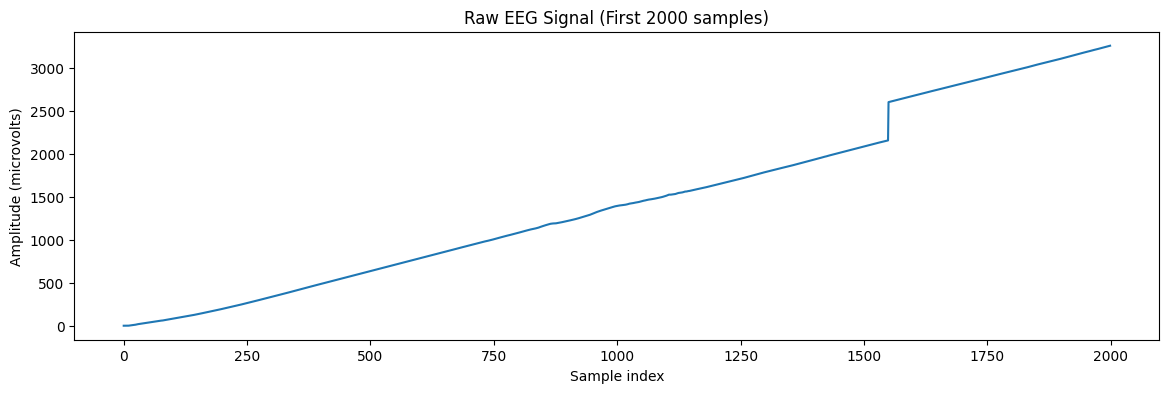

In [ ]:
# Ensure the EEG column is numeric, coercing errors to NaN
df[eeg_col] = pd.to_numeric(df[eeg_col], errors='coerce')

# Convert the data to a NumPy array of floats to explicitly ensure numerical type for plotting
eeg_data_to_plot = df[eeg_col].values[:2000].astype(float)

plt.figure(figsize=(14,4))
plt.plot(eeg_data_to_plot)
plt.title("Raw EEG Signal (First 2000 samples)")
plt.xlabel("Sample index")
plt.ylabel("Amplitude (microvolts)")
plt.show()

In [ ]:
class EEGFeatureExtractor:
    """Extract relevant features from EEG signals for BIS prediction"""

    def __init__(self, sampling_rate=128): #128=1sec
        self.fs = sampling_rate

    def extract_power_bands(self, eeg_segment):
        """Extract power in different frequency bands"""
        # Remove DC component
        eeg_segment = eeg_segment - np.mean(eeg_segment)

        # Compute power spectral density
        freqs, psd = signal.welch(eeg_segment, fs=self.fs, nperseg=min(256, len(eeg_segment))) #to change

        # Define frequency bands
        bands = {
            'delta': (0.5, 4),
            'theta': (4, 8),
            'alpha': (8, 13),
            'beta': (13, 30),
            'gamma': (30, 47)
        }

        # Calculate power in each band
        band_powers = {}
        for band_name, (low, high) in bands.items():
            idx = np.logical_and(freqs >= low, freqs <= high)
            band_powers[band_name] = np.trapezoid(psd[idx], freqs[idx]) # Changed np.trapz to np.trapezoid

        # Total power
        total_power = sum(band_powers.values())

        # Relative band powers (normalized)
        rel_powers = {k: v/total_power if total_power > 0 else 0
                      for k, v in band_powers.items()}

        return band_powers, rel_powers

    def calculate_spectral_edge_frequency(self, eeg_segment, percentile=95):
        """SEF95: Frequency below which 95% of power resides"""
        freqs, psd = signal.welch(eeg_segment, fs=self.fs, nperseg=min(256, len(eeg_segment)))

        cumulative_power = np.cumsum(psd)
        total_power = cumulative_power[-1]
        threshold = (percentile / 100) * total_power
        idx = np.where(cumulative_power >= threshold)[0]

        return freqs[idx[0]] if len(idx) > 0 else freqs[-1]

    def calculate_burst_suppression_ratio(self, eeg_segment, threshold=None):
        """BSR: Ratio of suppressed to total time"""
        if threshold is None:
            threshold = 0.1 * np.std(eeg_segment)

        suppressed = np.abs(eeg_segment) < threshold
        return np.sum(suppressed) / len(eeg_segment)

    def calculate_sample_entropy(self, eeg_segment, m=2, r=None):
        """Sample Entropy: Measure of signal complexity"""
        if r is None:
            r = 0.2 * np.std(eeg_segment)

        N = len(eeg_segment)

        def _maxdist(xmi, xmj):
            return max([abs(ua - va) for ua, va in zip(xmi, xmj)])

        def _phi(m):
            x = [[eeg_segment[j] for j in range(i, i + m)] for i in range(N - m + 1)]
            C = [len([1 for x_j in x if _maxdist(x_i, x_j) <= r]) / (N - m + 1.0) for x_i in x]
            return (N - m + 1.0)**(-1) * sum(np.log(C))

        try:
            return abs(_phi(m) - _phi(m + 1))
        except:
            return 0.5

    def extract_all_features(self, eeg_segment):
        """Extract all relevant features for BIS prediction"""
        features = {}

        # Power band features
        abs_powers, rel_powers = self.extract_power_bands(eeg_segment)

        # Key ratios for anesthesia depth
        features['alpha_delta_ratio'] = (rel_powers['alpha'] / rel_powers['delta']
                                          if rel_powers['delta'] > 0 else 0)
        features['beta_alpha_ratio'] = (rel_powers['beta'] / rel_powers['alpha']
                                         if rel_powers['alpha'] > 0 else 0)
        features['relative_beta'] = rel_powers['beta']
        features['relative_alpha'] = rel_powers['alpha']
        features['relative_delta'] = rel_powers['delta']

        # Spectral edge frequency (normalized)
        features['sef95'] = self.calculate_spectral_edge_frequency(eeg_segment) / 50.0

        # Burst suppression ratio
        features['bsr'] = self.calculate_burst_suppression_ratio(eeg_segment)

        # Sample entropy (normalized)
        features['sample_entropy'] = min(self.calculate_sample_entropy(eeg_segment), 2.0) / 2.0

        return features

print("EEG Feature Extractor defined successfully!")

EEG Feature Extractor defined successfully!


In [ ]:
class FuzzyMembershipFunction:
    """Define various membership function shapes"""

    @staticmethod
    def triangular(x, a, b, c):
        """Triangular membership function"""
        return np.maximum(0, np.minimum((x - a) / (b - a + 1e-10), (c - x) / (c - b + 1e-10)))

    @staticmethod
    def trapezoidal(x, a, b, c, d):
        """Trapezoidal membership function"""
        return np.maximum(0, np.minimum(np.minimum((x - a) / (b - a + 1e-10), 1),
                                        (d - x) / (d - c + 1e-10)))

    @staticmethod
    def gaussian(x, mean, sigma):
        """Gaussian membership function"""
        return np.exp(-((x - mean) ** 2) / (2 * sigma ** 2))

print("Fuzzy Membership Functions defined successfully!")

Fuzzy Membership Functions defined successfully!


In [ ]:
class FuzzyBISPredictor:
    """Fuzzy Inference System for BIS prediction using Mamdani method"""

    def __init__(self):
        self.input_fuzzy_sets = self._define_input_fuzzy_sets()
        self.output_fuzzy_sets = self._define_output_fuzzy_sets()
        self.rules = self._define_fuzzy_rules()

    def _define_input_fuzzy_sets(self):
        """Define fuzzy sets for input features"""
        fuzzy_sets = {}

        # Alpha/Delta Ratio: Higher = more awake
        fuzzy_sets['alpha_delta_ratio'] = {
            'low': lambda x: FuzzyMembershipFunction.trapezoidal(x, 0, 0, 0.3, 0.6),
            'medium': lambda x: FuzzyMembershipFunction.triangular(x, 0.4, 0.8, 1.2),
            'high': lambda x: FuzzyMembershipFunction.trapezoidal(x, 1.0, 1.5, 3.0, 3.0)
        }

        # Beta/Alpha Ratio: Higher = more awake
        fuzzy_sets['beta_alpha_ratio'] = {
            'low': lambda x: FuzzyMembershipFunction.trapezoidal(x, 0, 0, 0.5, 1.0),
            'medium': lambda x: FuzzyMembershipFunction.triangular(x, 0.8, 1.2, 1.6),
            'high': lambda x: FuzzyMembershipFunction.trapezoidal(x, 1.4, 2.0, 5.0, 5.0)
        }

        # SEF95: Lower = deeper anesthesia
        fuzzy_sets['sef95'] = {
            'low': lambda x: FuzzyMembershipFunction.trapezoidal(x, 0, 0, 0.3, 0.5),
            'medium': lambda x: FuzzyMembershipFunction.triangular(x, 0.4, 0.6, 0.8),
            'high': lambda x: FuzzyMembershipFunction.trapezoidal(x, 0.7, 0.9, 1.0, 1.0)
        }

        # BSR: Higher = deeper anesthesia
        fuzzy_sets['bsr'] = {
            'low': lambda x: FuzzyMembershipFunction.trapezoidal(x, 0, 0, 0.1, 0.3),
            'medium': lambda x: FuzzyMembershipFunction.triangular(x, 0.2, 0.4, 0.6),
            'high': lambda x: FuzzyMembershipFunction.trapezoidal(x, 0.5, 0.7, 1.0, 1.0)
        }

        # Sample Entropy: Lower = deeper anesthesia
        fuzzy_sets['sample_entropy'] = {
            'low': lambda x: FuzzyMembershipFunction.trapezoidal(x, 0, 0, 0.3, 0.5),
            'medium': lambda x: FuzzyMembershipFunction.triangular(x, 0.4, 0.6, 0.8),
            'high': lambda x: FuzzyMembershipFunction.trapezoidal(x, 0.7, 0.9, 1.0, 1.0)
        }

        return fuzzy_sets

    def _define_output_fuzzy_sets(self):
        """Define fuzzy sets for BIS output"""
        output_sets = {
            'deep': lambda x: FuzzyMembershipFunction.trapezoidal(x, 0, 0, 20, 40),
            'moderate': lambda x: FuzzyMembershipFunction.triangular(x, 30, 50, 70),
            'light': lambda x: FuzzyMembershipFunction.triangular(x, 60, 75, 90),
            'awake': lambda x: FuzzyMembershipFunction.trapezoidal(x, 80, 90, 100, 100)
        }
        return output_sets

    def _define_fuzzy_rules(self):
        """Define fuzzy rules based on anesthesia knowledge"""
        rules = [
            # Deep anesthesia rules
            ({'bsr': 'high', 'sef95': 'low'}, 'deep', 1.0),
            ({'alpha_delta_ratio': 'low', 'bsr': 'high'}, 'deep', 0.9),
            ({'sample_entropy': 'low', 'bsr': 'medium'}, 'deep', 0.8),
            ({'sef95': 'low', 'sample_entropy': 'low'}, 'deep', 0.85),

            # Moderate anesthesia rules
            ({'bsr': 'medium', 'sef95': 'medium'}, 'moderate', 1.0),
            ({'alpha_delta_ratio': 'medium', 'sample_entropy': 'medium'}, 'moderate', 0.9),
            ({'bsr': 'low', 'sef95': 'low'}, 'moderate', 0.7),

            # Light sedation rules
            ({'bsr': 'low', 'sef95': 'high'}, 'light', 1.0),
            ({'alpha_delta_ratio': 'high', 'bsr': 'low'}, 'light', 0.9),
            ({'sample_entropy': 'high', 'bsr': 'low'}, 'light', 0.85),

            # Awake rules
            ({'alpha_delta_ratio': 'high', 'beta_alpha_ratio': 'high'}, 'awake', 1.0),
            ({'sef95': 'high', 'sample_entropy': 'high'}, 'awake', 0.95),
            ({'bsr': 'low', 'beta_alpha_ratio': 'high'}, 'awake', 0.9),
        ]
        return rules

    def fuzzify(self, features):
        """STEP 1: Convert crisp values to fuzzy membership degrees"""
        fuzzified = {}

        for feature_name, fuzzy_sets in self.input_fuzzy_sets.items():
            if feature_name in features:
                crisp_value = features[feature_name]
                fuzzified[feature_name] = {}

                for set_name, membership_func in fuzzy_sets.items():
                    fuzzified[feature_name][set_name] = membership_func(crisp_value)

        return fuzzified

    def apply_rules(self, fuzzified_inputs):
        """STEP 2: Apply fuzzy rules"""
        activated_outputs = {label: [] for label in self.output_fuzzy_sets.keys()}

        for antecedents, consequent, weight in self.rules:
            firing_strength = 1.0

            for feature, fuzzy_set in antecedents.items():
                if feature in fuzzified_inputs and fuzzy_set in fuzzified_inputs[feature]:
                    membership = fuzzified_inputs[feature][fuzzy_set]
                    firing_strength = min(firing_strength, membership)

            firing_strength *= weight

            if firing_strength > 0:
                activated_outputs[consequent].append(firing_strength)

        aggregated = {}
        for label, activations in activated_outputs.items():
            aggregated[label] = max(activations) if activations else 0

        return aggregated

    def defuzzify(self, activated_outputs, method='centroid'):
        """STEP 3: Convert fuzzy output to crisp BIS value"""
        bis_range = np.linspace(0, 100, 1000)
        aggregated_membership = np.zeros_like(bis_range)

        for label, activation in activated_outputs.items():
            if activation > 0:
                membership_func = self.output_fuzzy_sets[label]
                clipped = np.minimum(membership_func(bis_range), activation)
                aggregated_membership = np.maximum(aggregated_membership, clipped)

        if np.sum(aggregated_membership) > 0:
            centroid = np.sum(bis_range * aggregated_membership) / np.sum(aggregated_membership)
        else:
            centroid = 50

        return centroid

    def predict(self, features, defuzz_method='centroid'):
        """Complete fuzzy inference pipeline"""
        fuzzified = self.fuzzify(features)
        activated = self.apply_rules(fuzzified)
        bis_value = self.defuzzify(activated, method=defuzz_method)
        bis_value = np.clip(bis_value, 0, 100)

        return bis_value, fuzzified, activated

print("Fuzzy BIS Predictor defined successfully!")

Fuzzy BIS Predictor defined successfully!


In [ ]:
# Initialize components
extractor = EEGFeatureExtractor(sampling_rate=128)
predictor = FuzzyBISPredictor()

# Extract a test window
test_window = eeg_data_to_plot[1000:1256]  # 256 samples = 2 seconds at 128 Hz

# Extract features
features = extractor.extract_all_features(test_window)
print("\n=== Extracted Features ===")
for key, value in features.items():
    print(f"{key:25s}: {value:.4f}")

# Predict BIS
bis_value, fuzzified, activated = predictor.predict(features)

print(f"\n=== Predicted BIS: {bis_value:.2f} ===")

# Show fuzzified values
print("\n=== Fuzzified Values ===")
for feature, memberships in fuzzified.items():
    print(f"\n{feature}:")
    for set_name, degree in memberships.items():
        print(f"  {set_name:10s}: {degree:.3f}")

# Show activated outputs
print("\n=== Output Activation Levels ===")
for output_name, activation in activated.items():
    print(f"{output_name:10s}: {activation:.3f}")


=== Extracted Features ===
alpha_delta_ratio        : 0.0002
beta_alpha_ratio         : 0.6696
relative_beta            : 0.0001
relative_alpha           : 0.0002
relative_delta           : 0.9985
sef95                    : 0.0100
bsr                      : 0.0000
sample_entropy           : 0.0028

=== Predicted BIS: 16.16 ===

=== Fuzzified Values ===

alpha_delta_ratio:
  low       : 1.000
  medium    : 0.000
  high      : 0.000

beta_alpha_ratio:
  low       : 0.661
  medium    : 0.000
  high      : 0.000

sef95:
  low       : 1.000
  medium    : 0.000
  high      : 0.000

bsr:
  low       : 0.000
  medium    : 0.000
  high      : 0.000

sample_entropy:
  low       : 1.000
  medium    : 0.000
  high      : 0.000

=== Output Activation Levels ===
deep      : 0.850
moderate  : 0.000
light     : 0.000
awake     : 0.000


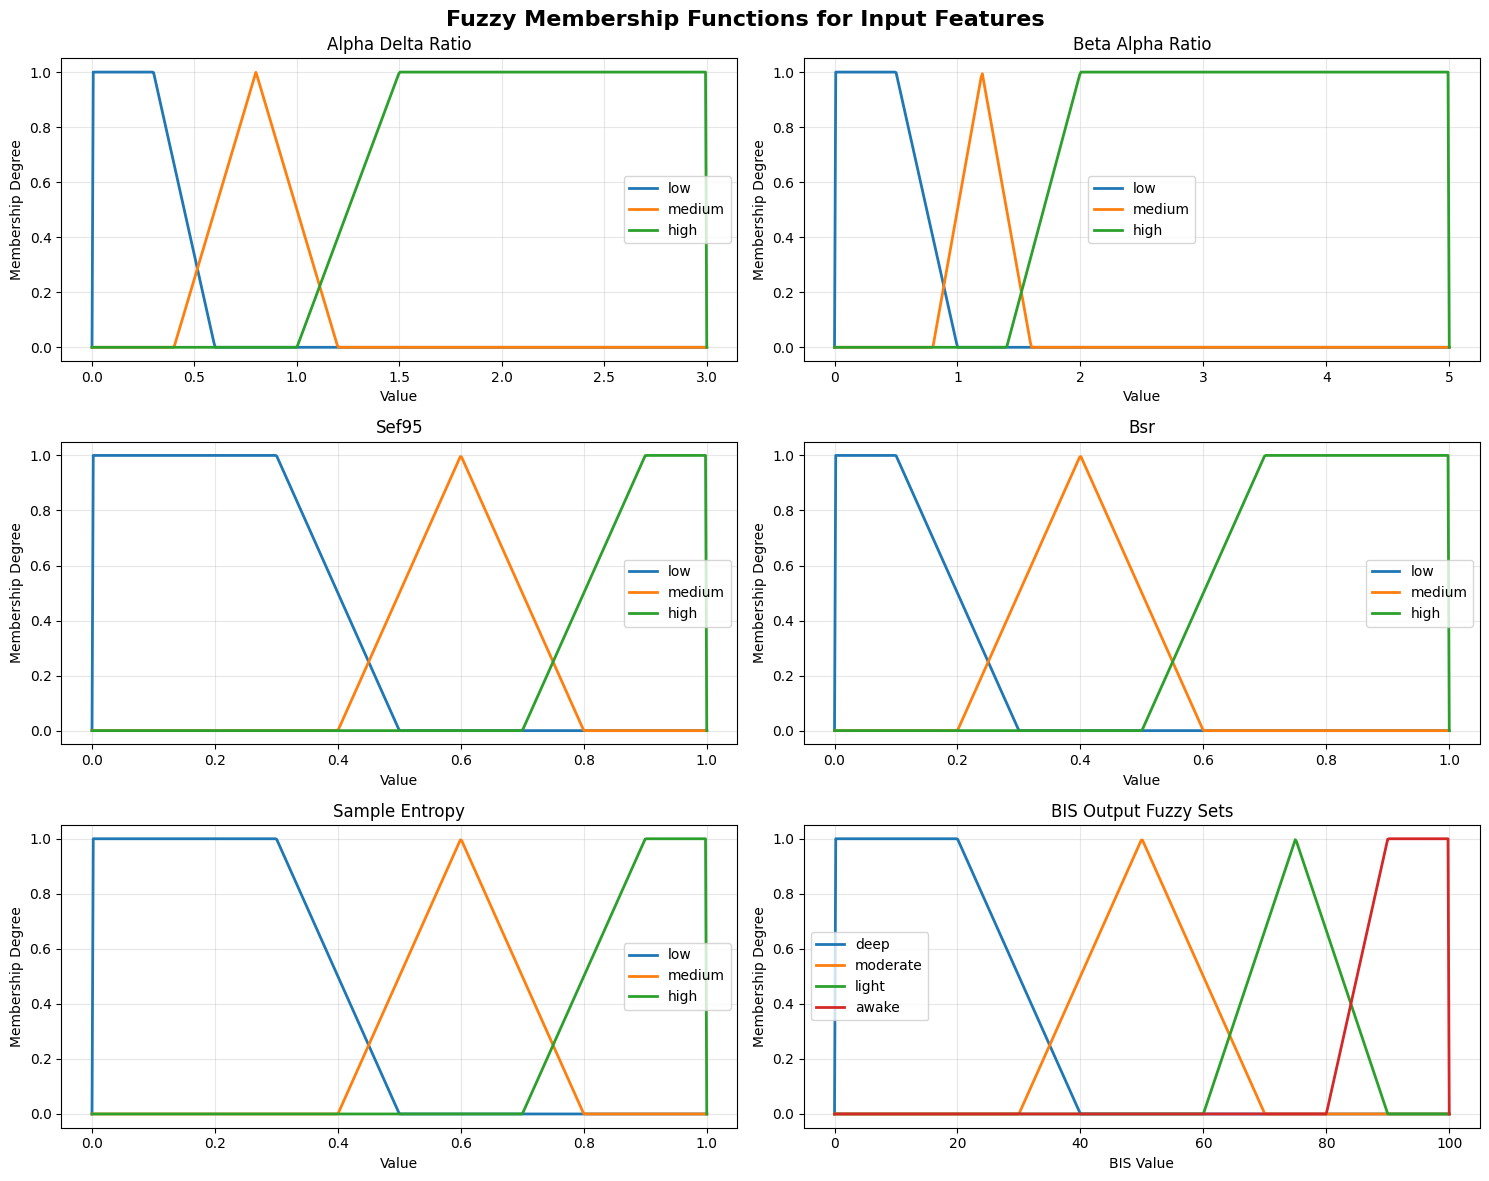

In [ ]:
# Visualize input membership functions
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('Fuzzy Membership Functions for Input Features', fontsize=16, fontweight='bold')

features_to_plot = [
    ('alpha_delta_ratio', 0, 3),
    ('beta_alpha_ratio', 0, 5),
    ('sef95', 0, 1),
    ('bsr', 0, 1),
    ('sample_entropy', 0, 1)
]

for idx, (feature, xmin, xmax) in enumerate(features_to_plot):
    ax = axes[idx // 2, idx % 2]
    x = np.linspace(xmin, xmax, 500)

    for set_name, func in predictor.input_fuzzy_sets[feature].items():
        y = func(x)
        ax.plot(x, y, label=set_name, linewidth=2)

    ax.set_xlabel('Value')
    ax.set_ylabel('Membership Degree')
    ax.set_title(feature.replace('_', ' ').title())
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-0.05, 1.05])

# Plot output membership functions
ax = axes[2, 1]
x = np.linspace(0, 100, 500)
for set_name, func in predictor.output_fuzzy_sets.items():
    y = func(x)
    ax.plot(x, y, label=set_name, linewidth=2)
ax.set_xlabel('BIS Value')
ax.set_ylabel('Membership Degree')
ax.set_title('BIS Output Fuzzy Sets')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([-0.05, 1.05])

plt.tight_layout()
plt.show()

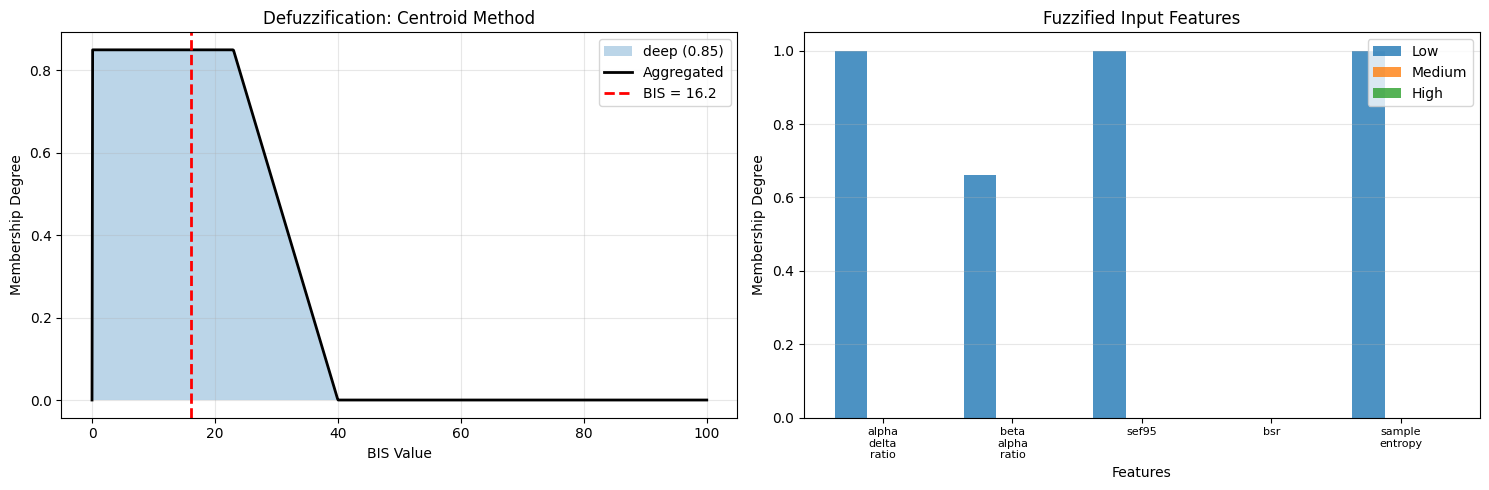

In [ ]:
# Visualize the defuzzification process
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Activated membership functions and centroid
bis_range = np.linspace(0, 100, 1000)
aggregated = np.zeros_like(bis_range)

for label, activation in activated.items():
    if activation > 0:
        membership_func = predictor.output_fuzzy_sets[label]
        clipped = np.minimum(membership_func(bis_range), activation)
        ax1.fill_between(bis_range, 0, clipped, alpha=0.3, label=f'{label} ({activation:.2f})')
        aggregated = np.maximum(aggregated, clipped)

ax1.plot(bis_range, aggregated, 'k-', linewidth=2, label='Aggregated')
ax1.axvline(bis_value, color='red', linestyle='--', linewidth=2, label=f'BIS = {bis_value:.1f}')
ax1.set_xlabel('BIS Value')
ax1.set_ylabel('Membership Degree')
ax1.set_title('Defuzzification: Centroid Method')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Input feature membership degrees
feature_names = []
low_vals, med_vals, high_vals = [], [], []

for feature in fuzzified:
    if 'low' in fuzzified[feature]:
        feature_names.append(feature.replace('_', '\n'))
        low_vals.append(fuzzified[feature].get('low', 0))
        med_vals.append(fuzzified[feature].get('medium', 0))
        high_vals.append(fuzzified[feature].get('high', 0))

x = np.arange(len(feature_names))
width = 0.25

ax2.bar(x - width, low_vals, width, label='Low', alpha=0.8)
ax2.bar(x, med_vals, width, label='Medium', alpha=0.8)
ax2.bar(x + width, high_vals, width, label='High', alpha=0.8)

ax2.set_xlabel('Features')
ax2.set_ylabel('Membership Degree')
ax2.set_title('Fuzzified Input Features')
ax2.set_xticks(x)
ax2.set_xticklabels(feature_names, fontsize=8)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
# Processing parameters
window_size = 256  # 2 seconds at 128 Hz
overlap = 128      # 50% overlap
step = window_size - overlap

# Process all windows
results = []
num_windows = (len(eeg_data_to_plot) - window_size) // step

print(f"Processing {num_windows} windows...")

for i in range(0, len(eeg_data_to_plot) - window_size, step):
    window = eeg_data_to_plot[i:i+window_size]

    # Extract features
    features = extractor.extract_all_features(window)

    # Predict BIS
    bis_pred, fuzz, act = predictor.predict(features)

    results.append({
        'sample_index': i + window_size//2,
        'time_seconds': (i + window_size//2) / 128,
        'predicted_bis': bis_pred,
        **features
    })

    if (len(results) % 100) == 0:
        print(f"  Processed {len(results)}/{num_windows} windows...")

results_df = pd.DataFrame(results)
print(f"\nComplete! Generated {len(results_df)} predictions.")
results_df.head()

Processing 13 windows...

Complete! Generated 14 predictions.


,sample_index,time_seconds,predicted_bis,alpha_delta_ratio,beta_alpha_ratio,relative_beta,relative_alpha,relative_delta,sef95,bsr,sample_entropy
0,128,1.0,29.718813,3.891398e-06,5.338703,2.077253e-05,3.890932e-06,0.999880,0.02,0.078125,0.001651
1,256,2.0,16.157938,6.901155e-07,0.363135,2.505998e-07,6.901013e-07,0.999979,0.02,0.000000,0.001041
2,384,3.0,16.157938,6.146980e-07,0.461993,2.839797e-07,6.146844e-07,0.999978,0.02,0.000000,0.001361
3,512,4.0,16.157938,6.324709e-07,0.395266,2.499886e-07,6.324574e-07,0.999979,0.01,0.000000,0.001378
4,640,5.0,16.157938,1.354595e-06,0.752830,1.019753e-06,1.354560e-06,0.999974,0.02,0.000000,0.001381


In [ ]:
# Add actual BIS values if column exists
if bis_col and bis_col in df.columns:
    print(f"Adding actual BIS values from column '{bis_col}'...")
    df[bis_col] = pd.to_numeric(df[bis_col], errors='coerce')

    # Align actual BIS with predicted
    for idx, row in results_df.iterrows():
        sample_idx = int(row['sample_index'])
        if sample_idx < len(df):
            results_df.loc[idx, 'actual_bis'] = df[bis_col].iloc[sample_idx]

    # Calculate error metrics
    valid = results_df.dropna(subset=['actual_bis'])
    if len(valid) > 0:
        mae = np.mean(np.abs(valid['predicted_bis'] - valid['actual_bis']))
        rmse = np.sqrt(np.mean((valid['predicted_bis'] - valid['actual_bis'])**2))
        print(f"\nPrediction Performance:")
        print(f"  Mean Absolute Error (MAE): {mae:.2f}")
        print(f"  Root Mean Square Error (RMSE): {rmse:.2f}")
else:
    print("No BIS column found. Skipping comparison.")

Adding actual BIS values from column 'BIS'...

Prediction Performance:
  Mean Absolute Error (MAE): 17.13
  Root Mean Square Error (RMSE): 17.48


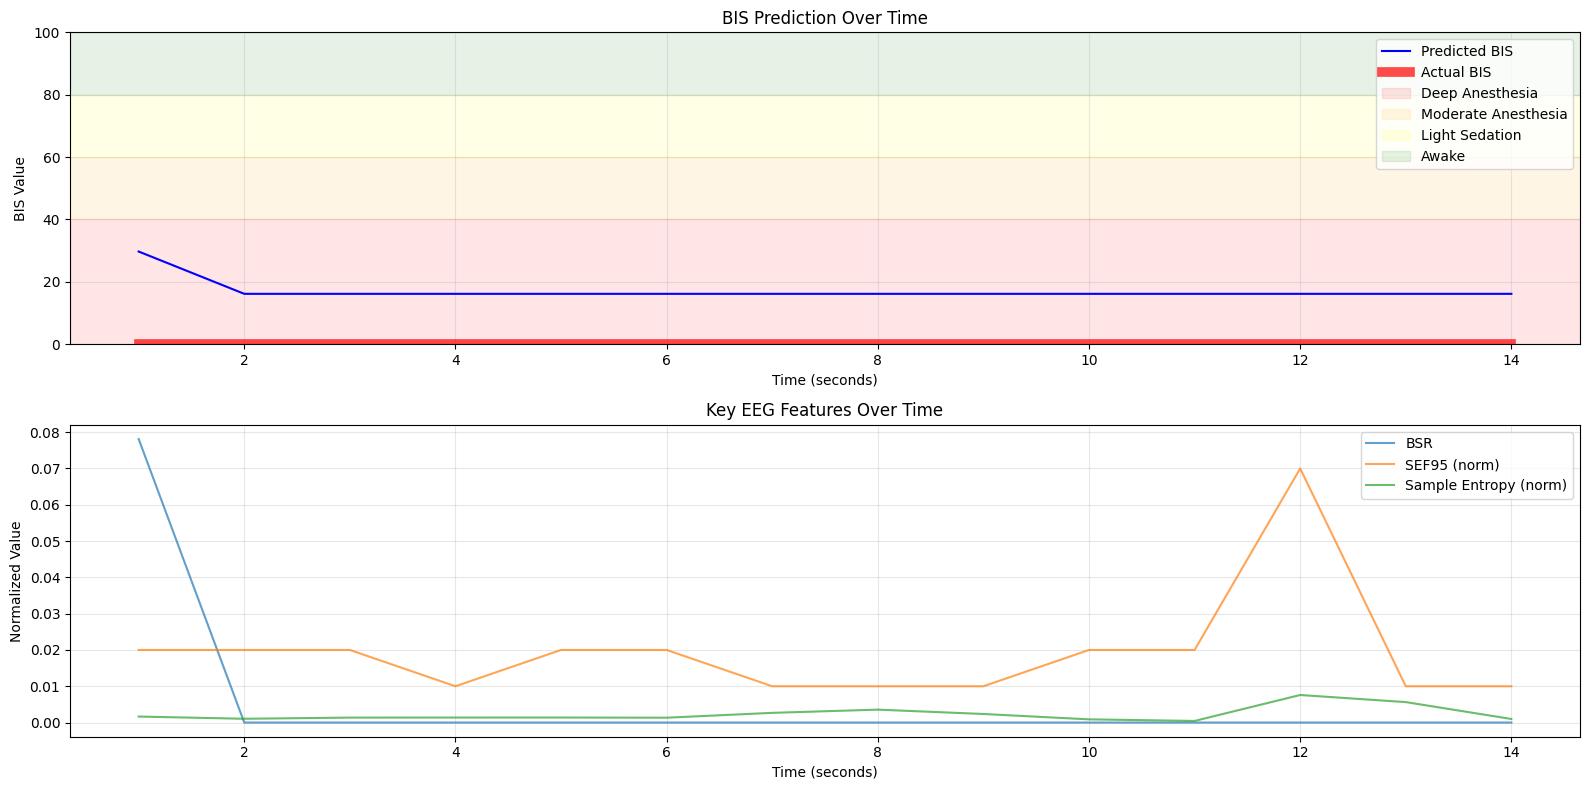

In [ ]:
# Plot predicted BIS over time
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Plot 1: Predicted BIS
axes[0].plot(results_df['time_seconds'], results_df['predicted_bis'], 'b-', linewidth=1.5, label='Predicted BIS')
if 'actual_bis' in results_df.columns:
    axes[0].plot(results_df['time_seconds'], results_df['actual_bis'], 'r-', linewidth=7, alpha=0.7, label='Actual BIS')

# Add anesthesia depth zones
axes[0].axhspan(0, 40, alpha=0.1, color='red', label='Deep Anesthesia')
axes[0].axhspan(40, 60, alpha=0.1, color='orange', label='Moderate Anesthesia')
axes[0].axhspan(60, 80, alpha=0.1, color='yellow', label='Light Sedation')
axes[0].axhspan(80, 100, alpha=0.1, color='green', label='Awake')

axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('BIS Value')
axes[0].set_title('BIS Prediction Over Time')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 100])

# Plot 2: Key features over time
axes[1].plot(results_df['time_seconds'], results_df['bsr'], label='BSR', alpha=0.7)
axes[1].plot(results_df['time_seconds'], results_df['sef95'], label='SEF95 (norm)', alpha=0.7)
axes[1].plot(results_df['time_seconds'], results_df['sample_entropy'], label='Sample Entropy (norm)', alpha=0.7)
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Normalized Value')
axes[1].set_title('Key EEG Features Over Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()